In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path="/eos/user/p/pmourafr/RootFiles/mc16_13TeV.sgn.MC.gammajet.bkg.vetoMC.dijet/mc16_13TeV.sgn.MC.gammajet.bkg.vetoMC.dijet_et1_eta1.npz"

In [3]:
data = np.load(data_path)

In [4]:
for x in data.keys():
    print(x)

features
etBins
etaBins
etBinIdx
etaBinIdx
data
target


In [5]:
indices_where = np.where(data.get("features") == "L2Calo_ring_0")
print(f"Indices using np.where: {indices_where}")

indices_where = np.where(data.get("features") == "L2Calo_ring_99")
print(f"Indices using np.where: {indices_where}")

Indices using np.where: (array([1]),)
Indices using np.where: (array([100]),)


In [6]:
data_path = "../results/config_nameRun2_ModelV1_fix_BCELoss_Adam_id20260311210612/repeat4.fold_idx0.iet1.ieta1.pkl"

In [7]:
unpickled_df = pd.read_pickle(data_path)

In [8]:
unpickled_df[['file_path', 'fold', 'best_sp_value', 'best_fa_value', 'best_pd_value', 'history']]

,file_path,fold,best_sp_value,best_fa_value,best_pd_value,history
0,/eos/user/p/pmourafr/RootFiles/mc16_13TeV.sgn....,0,0.974328,0.027557,0.976215,"{'train_loss': [0.04741295738805701, 0.0429701..."
1,/eos/user/p/pmourafr/RootFiles/mc16_13TeV.sgn....,0,0.973445,0.027891,0.974783,"{'train_loss': [0.046431452172717706, 0.042488..."
2,/eos/user/p/pmourafr/RootFiles/mc16_13TeV.sgn....,0,0.973880,0.027308,0.975069,"{'train_loss': [0.04601978661439755, 0.0425130..."
3,/eos/user/p/pmourafr/RootFiles/mc16_13TeV.sgn....,0,0.973828,0.027699,0.975356,"{'train_loss': [0.04619112119878932, 0.0423853..."
4,/eos/user/p/pmourafr/RootFiles/mc16_13TeV.sgn....,0,0.974261,0.025306,0.973827,"{'train_loss': [0.04684940031497538, 0.0428607..."


In [9]:
best_models = unpickled_df.iloc[1]

In [10]:
for x in data.keys():
    print(x)

features
etBins
etaBins
etBinIdx
etaBinIdx
data
target


In [11]:
eta_index = np.where(data.get("features") == "eta")
print(f"{eta_index = }")
et_index = np.where(data.get("features") == "et")
print(f"{et_index = }")

data.get("features")


eta_index = (array([121]),)
et_index = (array([120]),)


array(['avgmu', 'L2Calo_ring_0', 'L2Calo_ring_1', 'L2Calo_ring_2',
       'L2Calo_ring_3', 'L2Calo_ring_4', 'L2Calo_ring_5', 'L2Calo_ring_6',
       'L2Calo_ring_7', 'L2Calo_ring_8', 'L2Calo_ring_9',
       'L2Calo_ring_10', 'L2Calo_ring_11', 'L2Calo_ring_12',
       'L2Calo_ring_13', 'L2Calo_ring_14', 'L2Calo_ring_15',
       'L2Calo_ring_16', 'L2Calo_ring_17', 'L2Calo_ring_18',
       'L2Calo_ring_19', 'L2Calo_ring_20', 'L2Calo_ring_21',
       'L2Calo_ring_22', 'L2Calo_ring_23', 'L2Calo_ring_24',
       'L2Calo_ring_25', 'L2Calo_ring_26', 'L2Calo_ring_27',
       'L2Calo_ring_28', 'L2Calo_ring_29', 'L2Calo_ring_30',
       'L2Calo_ring_31', 'L2Calo_ring_32', 'L2Calo_ring_33',
       'L2Calo_ring_34', 'L2Calo_ring_35', 'L2Calo_ring_36',
       'L2Calo_ring_37', 'L2Calo_ring_38', 'L2Calo_ring_39',
       'L2Calo_ring_40', 'L2Calo_ring_41', 'L2Calo_ring_42',
       'L2Calo_ring_43', 'L2Calo_ring_44', 'L2Calo_ring_45',
       'L2Calo_ring_46', 'L2Calo_ring_47', 'L2Calo_ring_48',
       

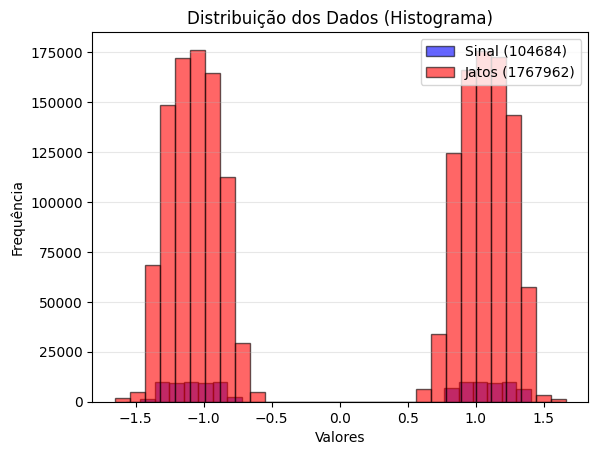

In [13]:
feature_values = data.get("data")[:,eta_index]

data_eta_signal = feature_values[np.where(data.get("target") == 1)].flatten()
data_eta_bg = feature_values[np.where(data.get("target") == 0)].flatten()
plt.hist(data_eta_signal, bins=30, color="blue", edgecolor='black', alpha=0.6, label=f'Sinal ({len(data_eta_signal)})')
plt.hist(data_eta_bg, bins=30, color="red", edgecolor='black', alpha=0.6, label=f'Jatos ({len(data_eta_bg)})')

plt.title('Distribuição dos Dados (Histograma)')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend(loc='upper right')

plt.grid(axis='y', alpha=0.3)

plt.show()

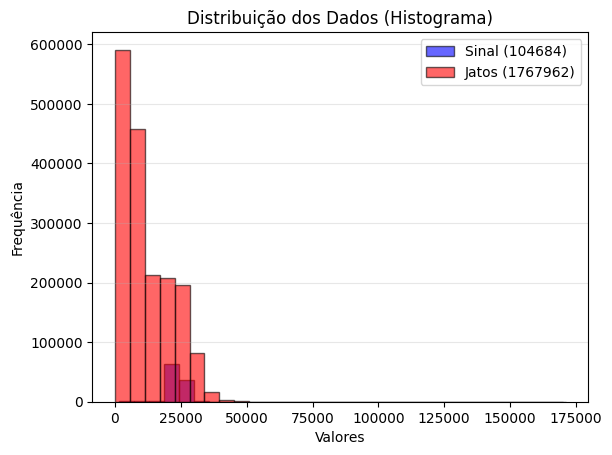

In [14]:
feature_values = data.get("data")[:,et_index]

data_eta_signal = feature_values[np.where(data.get("target") == 1)].flatten()
# data_eta_signal = data_eta_signal[(data_eta_signal > 20000) & (data_eta_signal < 30000)]
data_eta_bg = feature_values[np.where(data.get("target") == 0)].flatten()
# data_eta_bg = data_eta_bg[(data_eta_bg > 20000) & (data_eta_bg < 30000)]

plt.hist(data_eta_signal, bins=30, color="blue", edgecolor='black', alpha=0.6, label=f'Sinal ({len(data_eta_signal)})')
plt.hist(data_eta_bg, bins=30, color="red", edgecolor='black', alpha=0.6,  label=f'Jatos ({len(data_eta_bg)})')

plt.title('Distribuição dos Dados (Histograma)')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend(loc='upper right')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [15]:
88528/344669

0.2568493250045696

In [ ]:
251356/1767962 